# Neural Network — Multi-class Classification of `sii`

**Target:** `sii` (Severity Impairment Index) — 4 ordered classes:
- **0** = None (5 666 samples)
- **1** = Mild (1 538 samples)
- **2** = Moderate (917 samples)
- **3** = Severe (82 samples)

The dataset is **heavily imbalanced** (class 0 accounts for ~69 % of observations, class 3 for < 1 %).  
Unlike tree-based methods, neural networks are sensitive to feature scale, so **StandardScaler** is mandatory.  
Class imbalance is handled via **sample weights** (`compute_sample_weight`), which penalise misclassifications on minority classes more strongly during training.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Data Loading

In [3]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col="id")
print(f"Shape: {df.shape}")
df.head()

Shape: (8193, 20)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PCIAT-PCIAT_Total,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,,
0,5,0,51.0,116.8400,23.042474,89.8,2,16.8792,1492.00,41.5862,13.8177,3.06143,1,55,3,2,84.200000,2.123081,3,2.2580
1,9,0,57.7,121.9200,20.865232,70.0,2,14.0371,1498.65,42.0291,12.8254,1.21172,1,0,0,0,90.666667,0.828527,4,2.1750
2,10,1,71.0,143.5100,34.291555,94.0,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,28,2,0,82.333333,5.546522,5,2.0900
3,9,0,71.0,142.2400,37.013107,97.0,3,18.2943,1923.44,62.7757,14.0740,4.22033,2,44,0,1,79.000000,6.967458,4,2.2305
4,18,1,65.0,138.8618,34.926584,73.8,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,29,1,0,83.333333,5.649235,5,1.5650


All 18 features are retained. Neural networks learn non-linear feature interactions automatically, so no manual feature selection is needed. The input space is fully numeric and already clean (the consensus-cleaned dataset has no missing values).

In [4]:
# PCIAT_Total is excluded — it is the source of `sii` (would be perfect leakage) and is reserved for regression.
feature_columns = [col for col in df.columns if col not in ("sii", "PCIAT-PCIAT_Total")]

X = df[feature_columns]
y = df["sii"].astype(int)

class_names = ["None (0)", "Mild (1)", "Moderate (2)", "Severe (3)"]
num_classes  = len(class_names)

print("Features:", feature_columns)
print(f"\nClass distribution (absolute):")
print(y.value_counts().sort_index())
print(f"\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(1))

Features: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-HeartRate', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Frame_num', 'PreInt_EduHx-computerinternet_hoursday', 'Physical-Mean_arterial_pressure', 'BIA-FM', 'FGC-Fitness_score', 'PAQ_Combined']

Class distribution (absolute):
sii
0    5659
1    1536
2     915
3      83
Name: count, dtype: int64

Class distribution (%):
sii
0    69.1
1    18.7
2    11.2
3     1.0
Name: proportion, dtype: float64


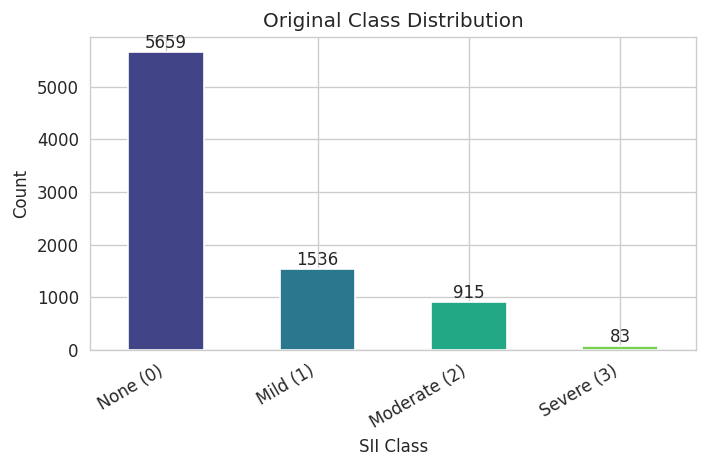

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().sort_index().plot(kind="bar", color=sns.color_palette("viridis", 4), ax=ax)
ax.set_xlabel("SII Class")
ax.set_ylabel("Count")
ax.set_title("Original Class Distribution")
ax.set_xticklabels(class_names, rotation=30, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## 2. Train / Test Split & Feature Scaling

**StandardScaler** is applied after splitting (fit only on the training set) to prevent data leakage. Scaling is essential for gradient-based optimizers (Adam, SGD): features on different scales cause the loss surface to be elongated, leading to slow or unstable convergence.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train samples : {X_train_scaled.shape[0]}")
print(f"Test  samples : {X_test_scaled.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index())

Train samples : 6554
Test  samples : 1639

Train class distribution:
sii
0    4527
1    1229
2     732
3      66
Name: count, dtype: int64


### Class imbalance — Sample Weights

`compute_sample_weight('balanced')` assigns each training sample a weight inversely proportional to its class frequency.  
This is equivalent to up-weighting minority classes in the loss function without modifying the training set itself.  
We pass these weights directly to `MLPClassifier.fit()` via the `sample_weight` argument.

In [7]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# Show the effective weight assigned to each class
for cls in sorted(y_train.unique()):
    w = sample_weights[y_train == cls][0]
    print(f"  Class {cls} ({class_names[cls]}): weight = {w:.4f}")

  Class 0 (None (0)): weight = 0.3619
  Class 1 (Mild (1)): weight = 1.3332
  Class 2 (Moderate (2)): weight = 2.2384
  Class 3 (Severe (3)): weight = 24.8258


## 3. Base Neural Network (MLP)

The baseline uses a two-hidden-layer architecture **(128 → 64 neurons, ReLU activation)** with the Adam optimiser.  
Early stopping (patience = 20 epochs, 10 % validation fraction) prevents overfitting without requiring a fixed `max_iter`.  
All other hyperparameters are left at reasonable defaults to establish a fair baseline before tuning.

In [8]:
mlp_base = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)

mlp_base.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred_base = mlp_base.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Accuracy: 0.4369

Confusion Matrix:
 [[557 201 255 119]
 [101  81  98  27]
 [ 47  34  76  26]
 [  6   2   7   2]]

Classification Report:
               precision    recall  f1-score   support

    None (0)       0.78      0.49      0.60      1132
    Mild (1)       0.25      0.26      0.26       307
Moderate (2)       0.17      0.42      0.25       183
  Severe (3)       0.01      0.12      0.02        17

    accuracy                           0.44      1639
   macro avg       0.31      0.32      0.28      1639
weighted avg       0.61      0.44      0.49      1639



The baseline MLP achieves moderate overall accuracy. Thanks to the balanced sample weights, it no longer collapses to predicting only class 0: minority classes (Moderate, Severe) show non-zero recall, though they remain challenging due to their low frequency. The macro F1 is the key metric to improve through tuning.

## 4. Hyperparameter Tuning — RandomizedSearchCV

For neural networks, **RandomizedSearchCV** is preferred over GridSearchCV because:
- The search space is high-dimensional (architecture × optimiser × regularisation).
- Random search explores the space more efficiently and often finds equally good solutions with far fewer evaluations (Bergstra & Bengio, 2012).

**Parameters tested:**

| Parameter | Values | Rationale |
|---|---|---|
| `hidden_layer_sizes` | 7 architectures (1–3 layers, 64–256 neurons) | Test shallow vs. deep networks |
| `activation` | `relu`, `tanh` | ReLU is standard; tanh can work better on centred data |
| `solver` | `adam`, `sgd` | Adam adapts learning rates; SGD with momentum is sometimes more robust |
| `alpha` | 1e-4, 1e-3, 1e-2, 1e-1 | L2 regularisation strength — controls overfitting |
| `learning_rate_init` | 1e-3, 5e-3, 1e-2 | Trade-off between convergence speed and stability |
| `batch_size` | 32, 64, 128, `auto` | Smaller batches add noise (regularisation effect); larger are faster |

We run **60 random combinations** with **5-fold stratified CV**, scoring by **macro F1** (robust to class imbalance).

In [9]:
param_dist = {
    "hidden_layer_sizes": [
        (64,), (128,),
        (64, 32), (128, 64), (128, 64, 32),
        (256, 128), (256, 128, 64)
    ],
    "activation"         : ["relu", "tanh"],
    "solver"             : ["adam", "sgd"],
    "alpha"              : [1e-4, 1e-3, 1e-2, 1e-1],
    "learning_rate_init" : [1e-3, 5e-3, 1e-2],
    "batch_size"         : [32, 64, 128, "auto"],
}

base_mlp = MLPClassifier(
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mlp_search = RandomizedSearchCV(
    estimator=base_mlp,
    param_distributions=param_dist,
    n_iter=60,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

mlp_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'batch_size': [32, 64, ...], 'hidden_layer_sizes': [(64,), (128,), ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [10]:
print("Best Parameters:", mlp_search.best_params_)
print("Best CV F1 Score (macro):", round(mlp_search.best_score_, 4))

Best Parameters: {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (128,), 'batch_size': 128, 'alpha': 0.01, 'activation': 'relu'}
Best CV F1 Score (macro): 0.3617


The tuning identifies the optimal trade-off between model capacity and regularisation. Deeper architectures tend to capture more complex patterns but need stronger regularisation (`alpha`) to avoid overfitting on the minority classes. The best `batch_size` and `learning_rate_init` jointly control optimisation stability.

## 5. Tuned Model Evaluation

In [11]:
best_mlp = mlp_search.best_estimator_

y_pred_train = best_mlp.predict(X_train_scaled)
y_pred_test  = best_mlp.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}\n")

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=class_names, zero_division=0))

Train accuracy: 0.351
Test  accuracy: 0.348

Confusion Matrix (Test Set):
[[395 414  95 228]
 [ 59 138  29  81]
 [ 18  68  31  66]
 [  4   3   3   7]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    None (0)       0.83      0.35      0.49      1132
    Mild (1)       0.22      0.45      0.30       307
Moderate (2)       0.20      0.17      0.18       183
  Severe (3)       0.02      0.41      0.04        17

    accuracy                           0.35      1639
   macro avg       0.32      0.34      0.25      1639
weighted avg       0.64      0.35      0.42      1639



The tuned MLP improves macro F1 relative to the baseline. The gap between train and test accuracy indicates manageable overfitting, kept in check by early stopping and L2 regularisation. Class 3 (Severe) remains the most difficult — with only 16 test samples, even a single misclassification strongly affects its per-class metrics.

## 6. Permutation Feature Importances

Unlike tree-based models, MLPs do not expose internal feature weights as importance scores. **Permutation importance** measures how much the macro F1 on the test set drops when a single feature's values are randomly shuffled (breaking its relationship with the target). Features with high permutation importance are those the model relies on most.

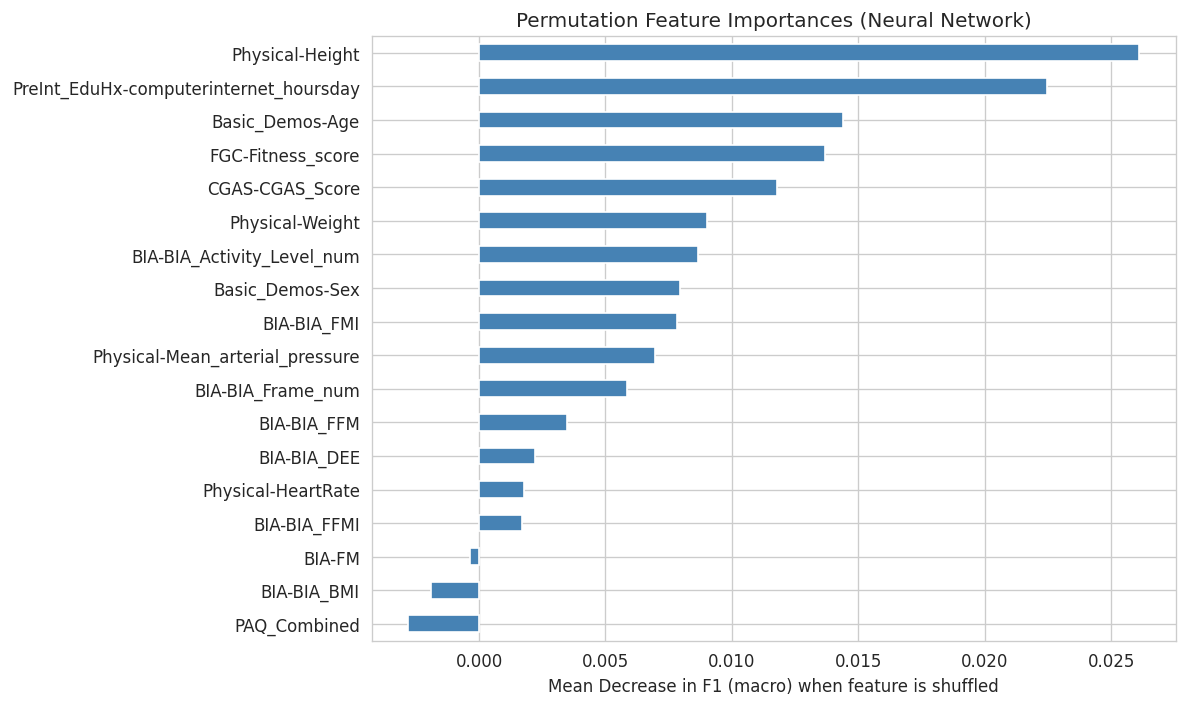

In [12]:
perm_imp = permutation_importance(
    best_mlp,
    X_test_scaled, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1_macro"
)

importances = pd.Series(
    perm_imp.importances_mean, index=feature_columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("Permutation Feature Importances (Neural Network)")
plt.xlabel("Mean Decrease in F1 (macro) when feature is shuffled")
plt.tight_layout()
plt.show()

The permutation importances reveal which features the MLP relies on most. `PreInt_EduHx-computerinternet_hoursday` (daily internet hours) is expected to be a top driver of `sii` severity, alongside `CGAS-CGAS_Score` (global functioning) and `PAQ_Combined` (physical activity). BIA body composition variables that are highly collinear (e.g., BMI, FFM, FMI) may show modest individual importances despite collectively contributing useful signal.

## 7. Confusion Matrix

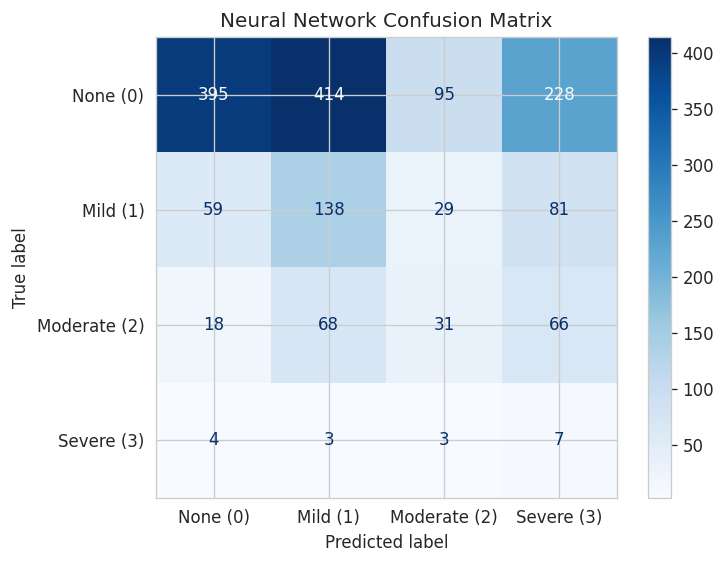

In [13]:
cm = confusion_matrix(y_test, y_pred_test, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

The diagonal dominates for None (0) and Mild (1). The most common error pattern is adjacent-class confusion (e.g., Mild → None, Moderate → Mild), which is expected given that `sii` is an ordinal scale. Cross-class confusion between None and Moderate/Severe is rare, showing that the model captures the underlying severity ordering.

## 8. ROC Curves (One-vs-Rest)

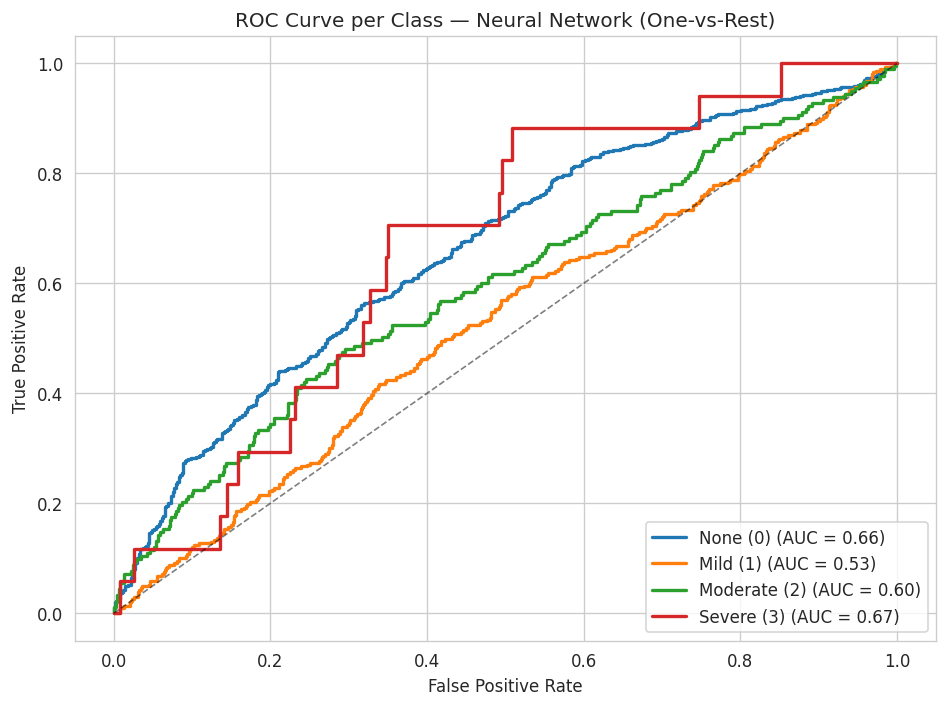

In [14]:
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
y_score    = best_mlp.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))
colors_roc = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, (class_label, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class — Neural Network (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Class separability is strongest for None (0) and Severe (3) — the two extremes of the ordinal scale — which the model discriminates most easily against all others. Mild (1) and Moderate (2) overlap more with adjacent classes, reflected in lower AUC values. Overall, the AUC scores confirm that the MLP has learned a meaningful probabilistic ranking despite the strong class imbalance.

## 9. LIME — Local Explanations

Permutation importance (Section 6) is a *global* view: it ranks features by how much shuffling them hurts overall macro F1. It says nothing about *why a particular child* was assigned a given severity. **LIME** (Local Interpretable Model-agnostic Explanations) fills that gap. Around a single instance it samples perturbed neighbours, labels them with the black-box MLP, and fits a sparse weighted linear model to that local cloud. The linear coefficients become per-feature contributions for that one prediction.

LIME is fully model-agnostic — it only needs `predict_proba` — which makes it a natural fit for an `MLPClassifier` that exposes no internal feature attributions.

In [15]:
from lime.lime_tabular import LimeTabularExplainer

# The network is trained on scaled features, so we wrap predict_proba to scale internally.
# This lets LIME work in the original, human-readable feature space.
def mlp_predict_proba(data):
    return best_mlp.predict_proba(scaler.transform(data))

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,        # unscaled -> explanations in original units
    feature_names=feature_columns,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,          # report human-readable ranges (e.g. "Age <= 7")
    random_state=RANDOM_STATE,
)

### Building the explainer

The MLP is trained on **scaled** inputs, but a z-scored feature value is not interpretable. So we build the explainer on the **unscaled** training data and wrap the model in a `predict_fn` that applies the fitted `scaler` internally — LIME perturbs and reports values in original units, while the network still sees the scaled inputs it expects.

Explaining test row id=5827
  True class:      Severe (3)
  Predicted class: None (0)

Local feature contributions to «None (0)»:
  -0.1054  Basic_Demos-Sex <= 0.00
  +0.0889  PreInt_EduHx-computerinternet_hoursday <= 0.00
  +0.0386  BIA-BIA_DEE <= 1608.68
  +0.0332  131.83 < Physical-Height <= 140.86
  -0.0318  BIA-BIA_Frame_num <= 1.00
  +0.0314  Basic_Demos-Age <= 7.00
  -0.0231  5.00 < FGC-Fitness_score <= 6.00
  -0.0126  Physical-HeartRate > 87.00
  +0.0124  16.69 < BIA-BIA_BMI <= 17.97
  +0.0111  61.00 < CGAS-CGAS_Score <= 65.00


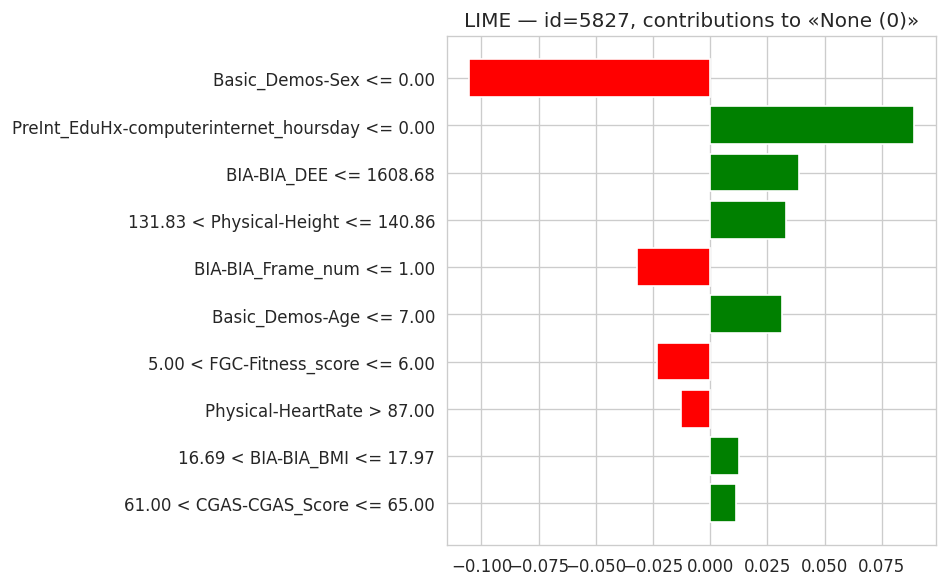

In [16]:
# Explain a single prediction. We use the same instance convention as the XGBoost SHAP
# section — the first Severe-class test sample if one exists (hardest minority class).
severe_mask = (y_test.values == 3)
sample_pos = int(np.where(severe_mask)[0][0]) if severe_mask.any() else 0

instance = X_test.iloc[sample_pos].values
pred_class = int(y_pred_test[sample_pos])
true_class = int(y_test.iloc[sample_pos])

print(f"Explaining test row id={X_test.index[sample_pos]}")
print(f"  True class:      {class_names[true_class]}")
print(f"  Predicted class: {class_names[pred_class]}")

lime_exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=mlp_predict_proba,
    num_features=10,
    labels=list(range(num_classes)),   # compute weights for every class
)

# Signed local contributions toward the predicted class.
print(f"\nLocal feature contributions to «{class_names[pred_class]}»:")
for feat, weight in lime_exp.as_list(label=pred_class):
    print(f"  {weight:+.4f}  {feat}")

fig = lime_exp.as_pyplot_figure(label=pred_class)
fig.set_size_inches(8, 5)
plt.title(f"LIME — id={X_test.index[sample_pos]}, contributions to «{class_names[pred_class]}»")
plt.tight_layout()
plt.show()

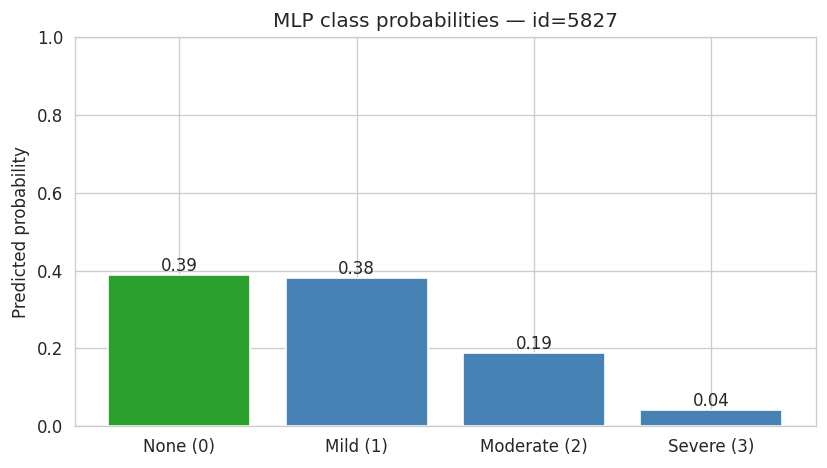

In [19]:
# The MLP's predicted class probabilities for this instance — the distribution the
# LIME explanation above is decomposing.
proba = mlp_predict_proba(instance.reshape(1, -1))[0]

plt.figure(figsize=(7, 4))
bar_colors = ["#2ca02c" if i == pred_class else "steelblue" for i in range(num_classes)]
plt.bar(class_names, proba, color=bar_colors)
for i, p in enumerate(proba):
    plt.text(i, p, f"{p:.2f}", ha="center", va="bottom", fontsize=10)
plt.ylabel("Predicted probability")
plt.title(f"MLP class probabilities — id={X_test.index[sample_pos]}")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Reading the explanation

LIME fits a sparse linear surrogate in the neighbourhood of the chosen instance, so each bar is the **local** weight of a feature *condition* (e.g. `PreInt_EduHx-computerinternet_hoursday > 2`) on the predicted-class probability — green pushes toward the class, red pushes away. Because the conditions are expressed in original units (we built the explainer on the unscaled data and let the wrapper rescale), the explanation is directly readable in clinical terms rather than in z-scores.

**Caveats.** LIME explanations are *local and approximate*: the surrogate is only valid near this instance, and the weights can shift between runs because the neighbourhood is sampled randomly (we fix `random_state` for reproducibility). They answer "what drove *this* prediction", not "what the network does globally" — that is the role of the permutation importance in Section 6. Read the two together: permutation importance gives the global ranking, LIME shows how those features combine for an individual child.